In [1]:
import torch
from dinosaw.models.vit_wrapper import MODEL_LIST, PretrainedViTWrapper, AlibiVitWrapper
from dinosaw.utils import do_2D_pca, to_numpy, closest_resize, convert_image

import numpy as np

from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import font_manager


SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)

/home/ronan/Documents/phd/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
S = 14
alibi_model = AlibiVitWrapper(
    MODEL_LIST[1],
    stride=S,
    add_flash_attn=False,
    device="cuda:0",
    slope_type="constant",
    normalize=True,
    wrap=True,
)

weights = torch.load("../../trained_models/alibi_dv2_vits14_reg.pth", weights_only=True, map_location="cuda:0")
alibi_model.load_state_dict(weights)
alibi_model.eval()
None

In [3]:
dv2_model = PretrainedViTWrapper(
    MODEL_LIST[1],
    stride=S,
    add_flash_attn=False,
    device="cuda:0",
)

dv2_model.eval()
None

In [4]:
def get_features(model: PretrainedViTWrapper, pil_img: Image.Image) -> np.ndarray:
    tr = closest_resize(pil_img.height, pil_img.width, 14)
    img_tensor = convert_image(pil_img, tr, device_str="cuda:0", to_half=False)
    with torch.no_grad():
        emb = model.forward_features(img_tensor, make_2D=True)
    emb_np = to_numpy(emb.squeeze(0))
    return emb_np

In [5]:
images: list[Image.Image] = []
path = 'data/cosine_sim/'


# Lazy: every image is landscape, fix a size
long_L = 0
for file_name in ('ducklings_crop.png', 'aquarium.jpg', 'beehive.jpg', 'nmc_ml50_crop_.png'):
    img = Image.open(f'{path}/{file_name}').convert('RGB')

    shortest = min(img.size)
    short_L = 518
    sf = short_L / shortest

    long_L = 1.5 * short_L

    new_size = (int(long_L), int(short_L))
    img = img.resize(new_size, resample=Image.LANCZOS)

    images.append(img)

In [6]:
features = {'dv2': [], 'alibi': []}

for image in images:
    for key, model in zip(('dv2', 'alibi'), [dv2_model, alibi_model]):
        feats = get_features(model, image)
        feats = np.transpose(feats, (1, 2, 0))
        h, w, c = feats.shape

        feats_flat = feats.reshape(-1, c)

        feats_normed = feats_flat / np.linalg.norm(feats_flat, axis=-1, keepdims=True)
        features[key].append(feats_normed.reshape(h, w, c))

In [7]:
%%capture
fig, axs = plt.subplots(len(images), 3, figsize=(12, 8))

i = 0
for image in images:
    j = 1
    axs[i, 0].imshow(image)

    for key, model in zip(('dv2', 'alibi'), [dv2_model, alibi_model]):
        emb = features[key][i]

        h, w, _ = emb.shape
        feats_red = do_2D_pca(np.transpose(emb, (2, 0, 1)), n_components=3, pre_norm='std', post_norm='minmax')
        axs[i, j].imshow(feats_red, cmap='coolwarm')
        j += 1

    for ax in axs[i]:
        ax.set_axis_off()
    i += 1

plt.tight_layout()

In [61]:
def add_custom_font(font_folder: str, font_name: str="Grotesk") -> None:
    try:
        font_paths = (f'{font_folder}/{font_name}.ttf', f'{font_folder}/{font_name}-Bold.ttf')
        for font_path in font_paths:
            font_manager.fontManager.addfont(font_path)
        prop = font_manager.FontProperties(fname=font_paths[0])

        plt.rcParams['font.family'] = 'sans-serif'
        plt.rcParams['font.sans-serif'] = prop.get_name()
    except Exception as e:
        print(f"Can't load custom font: {e} ")


def add_inset_zoom(xywh: list[int], fig_xywh: list[float], img_arr: np.ndarray, ax ) -> object:
    x0, y0, w, h = xywh
    H, W, C = img_arr.shape
    inset_data = np.zeros_like(img_arr)
    inset_data[y0:y0+h, x0:x0+w, :] = img_arr[y0:y0+h, x0:x0+w, :]

    axin = ax.inset_axes(
        fig_xywh, xlim=(x0, x0+w), ylim=(y0, y0+h))
    axin.set_xticks([])
    axin.set_yticks([])

    axin.imshow(inset_data) # cmap="binary_r"
    ax.indicate_inset_zoom(axin, edgecolor="red", lw=2)
    axin.set_ylim((y0 + h, y0))

    axin.patch.set_edgecolor('red')  
    axin.patch.set_linewidth(5)  

    return axin


/tmp/ipykernel_85665/1989200301.py:74: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


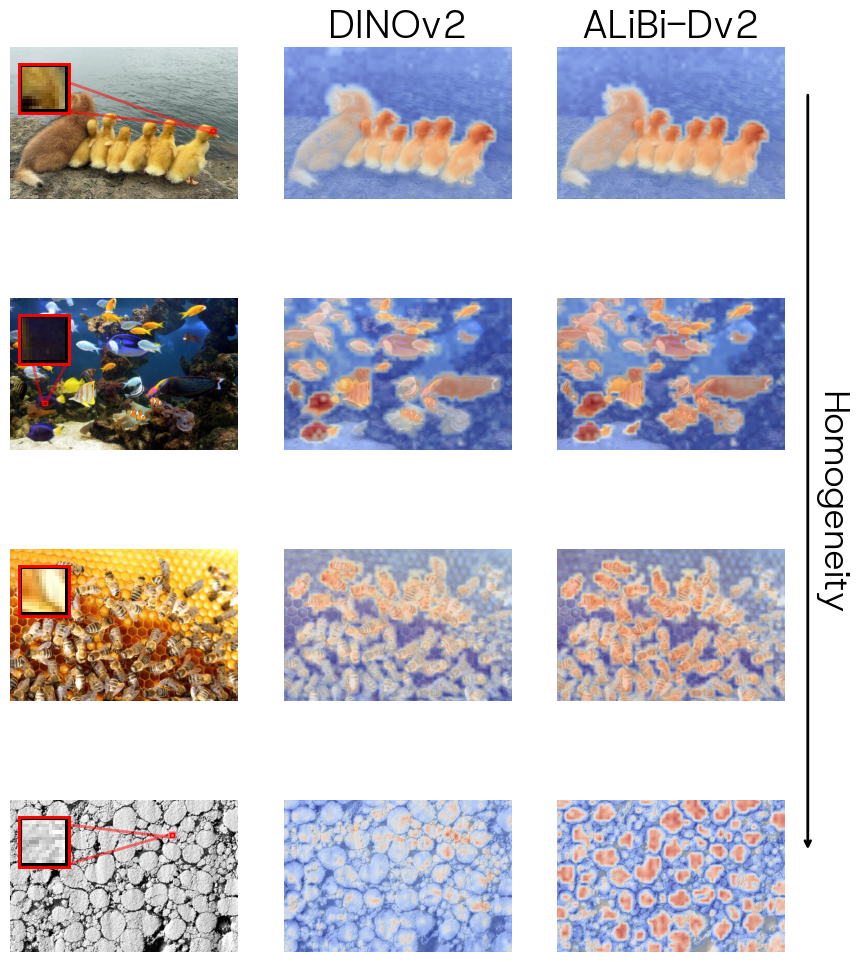

In [ ]:
# %%capture
from matplotlib.patches import Rectangle, Arrow
from numpy.linalg import norm

from skimage.transform import resize

add_custom_font('resources/fonts', 'Grotesk')

patch_locs = [(49, 20), (8, 25),  (9, 7),  (39, 8),]

W, H = 3, 2.5
FS = 28
titles = ("DINOv2", "ALiBi-Dv2")

fig, axs = plt.subplots(len(images), 3, figsize=(11, H * 5))

i = 0
for image in images:
    j = 1
    loc = patch_locs[i]
    axs[i, 0].imshow(image)

    add_inset_zoom(
        xywh=[loc[0] * S, loc[1] * S, S, S],
        fig_xywh=[0.05, 0.55, 0.2, 0.35],
        img_arr=np.array(image),
        ax=axs[i, 0])


    artist = Rectangle((loc[0] * S, loc[1] * S), S, S, color='red', fill=False, linewidth=1)
    axs[i, 0].add_artist(artist)

    for k, (key, model) in enumerate(zip(('dv2', 'alibi'), [dv2_model, alibi_model])):

        if i == 0:
            axs[0, j].set_title(f'{titles[k]}', fontsize=FS)

        emb = features[key][i]
        emb = emb.transpose(2, 0, 1)
        ref_emb = emb[:, loc[1], loc[0]]

        c, h, w = emb.shape

        flat = emb.reshape(emb.shape[0], -1)
        sim = np.dot(ref_emb, flat) / (norm(ref_emb) * norm(flat, axis=0) + 1e-8)
        sim = sim.reshape((h, w))

        sim_map_resized = resize(
        sim,
        (image.height, image.width),
        order=1,  # bilinear
        preserve_range=True,
        anti_aliasing=True
    )

        axs[i, j].imshow(image)
        axs[i, j].imshow(sim_map_resized, cmap='coolwarm', alpha=0.7, interpolation='bilinear',)
        axs[i, j].axis("off")

        j += 1

    for ax in axs[i]:
        ax.set_axis_off()
    i += 1


ARROW_X = 1.1
axs[0, 2].annotate('', xy=(ARROW_X, 0.7), xycoords='axes fraction', xytext=(ARROW_X, -4.3), 
            arrowprops=dict(arrowstyle="<-", color='black', linewidth=2))
axs[0, 2].text(ARROW_X + 0.1, -2, 'Homogeneity', transform=axs[0, 2].transAxes,
            fontsize=FS - 2, rotation=270, va='center', ha='center')


plt.tight_layout()
plt.savefig('saved/03c.png', dpi=300, bbox_inches='tight')